In [ ]:
# Import the standard library for math and arrays
import numpy as np 

# Import the library used for drawing graphs (plots)
import matplotlib.pyplot as plt 

# Tool to change a single feature (x) into polynomial features (x, x^2, x^3...)
from sklearn.preprocessing import PolynomialFeatures 

# The basic Linear Regression model we will use to fit the data
from sklearn.linear_model import LinearRegression 

# A math formula to calculate how "wrong" the model is (error)
from sklearn.metrics import mean_squared_error 

# Tool to automatically split data into two groups: Training and Validation
from sklearn.model_selection import train_test_split 

# 1. CREATE DATASET
# Set a 'seed' so that the random numbers are the same every time you run it (reproducible)
np.random.seed(42) 

# Create 500 random points between 0 and 5, and sort them from smallest to largest
# Generates a 500 × 1 array (500 rows, 1 column)
# Values are random floats between 0 and 1
# Multiplies every value by 5
# So range becomes 0 to 5
# Sorts the array column-wise
# Since it's a single column, it just sorts all 500 values in ascending order

# Generate 500 random values in range [0,5] and arrange them in increasing order.
X = np.sort(5 * np.random.rand(500, 1), axis=0) 

# Create 'y' using a Sine wave pattern + add some random "noise" to make it realistic
# ravel() just flattens the array into a simple list

# Applies sine function to each value in X
# Since X is (500,1), result is also (500,1)
# Converts array from shape (500,1) → (500,)
# Flattens it into a 1D array
# Generates 500 random values
# From a normal (Gaussian) distribution
# Mean = 0
# Standard deviation = 0.7
# This is noise
y = np.sin(X).ravel() + np.random.normal(0, 0.7, X.shape[0]) 


# 2. REQUIREMENT: SPLIT DATASET (70% Training, 30% Validation)
# X_train/y_train: The 70% the model will "study"
# X_val/y_val: The 30% the model will be "tested" on (unseen data)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.30, random_state=42)

# 3. VERIFY THE SPLIT
# These print statements prove to your instructor that the split was done correctly.
print(f"Total points: {len(X)}")             # Should show 200
print(f"Training points (70%): {len(X_train)}") # Should show 140
print(f"Validation points (30%): {len(X_val)}") # Should show 60

Total points: 500
Training points (70%): 350
Validation points (30%): 150


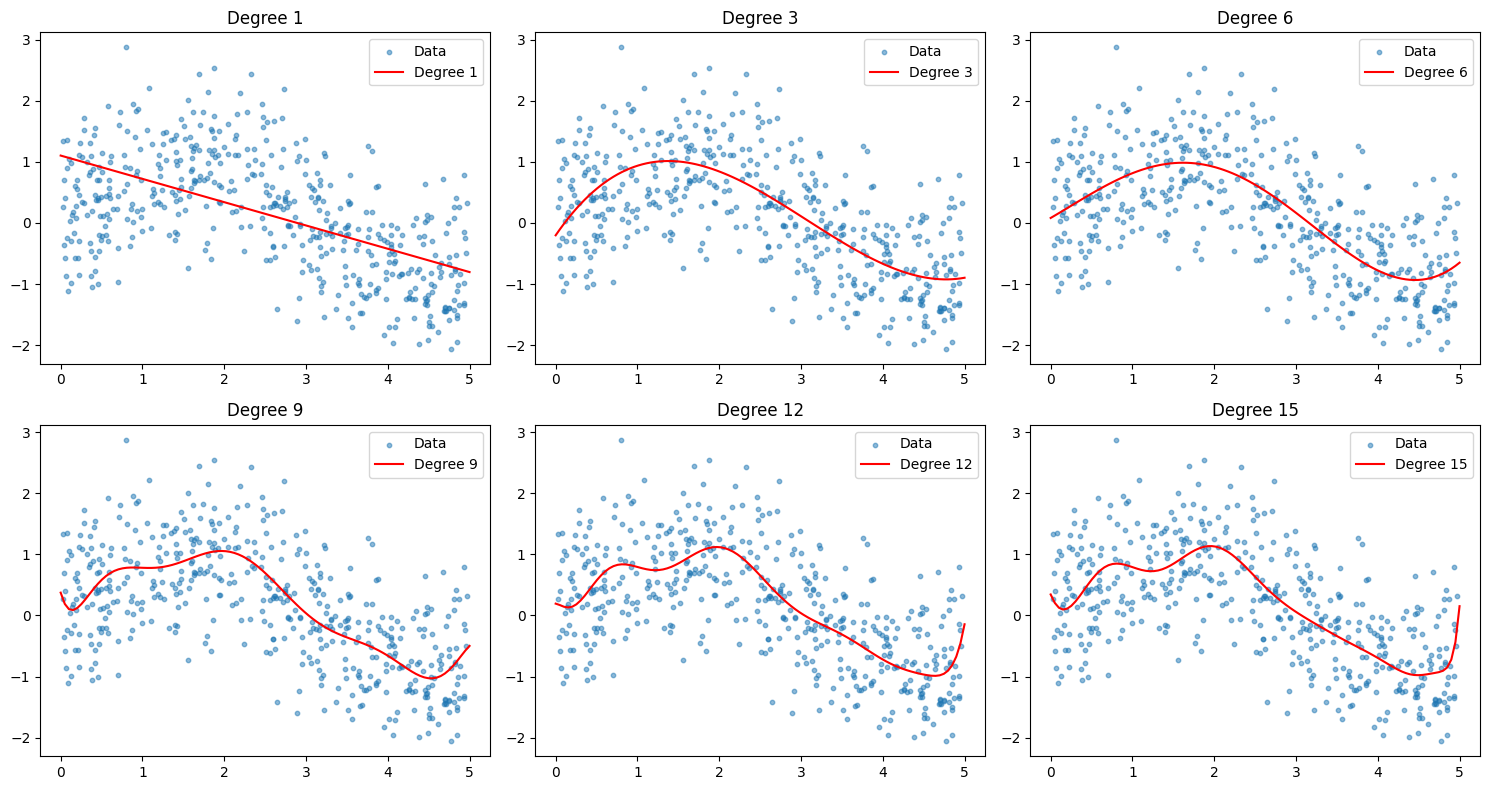

Degree | Train Error | Val Error
  1    |   0.6564   |  0.6264
  3    |   0.4958   |  0.5156
  6    |   0.4878   |  0.4994
  9    |   0.4795   |  0.5164
  12    |   0.4774   |  0.5198
  15    |   0.4765   |  0.5219


In [2]:
# REQUIREMENT: Define the polynomial degrees we want to test (1 to 5)
degrees = [1,3,6,9,12,15]

# Create empty lists to store the error scores for each degree
train_errors, val_errors = [], []

# Set the size of the overall figure for all 5 plots
plt.figure(figsize=(15, 8))

# Loop through each degree (d) and keep track of the index (i) for plotting
for i, d in enumerate(degrees):
    
    # 1. TRANSFORM DATA: Change X into polynomial features (e.g., Degree 2 turns X into X and X^2)
    poly = PolynomialFeatures(degree=d)
    
    # 'fit_transform' learns the pattern from training data and converts it
    X_poly_train = poly.fit_transform(X_train)
    
    # 'transform' converts validation data using the SAME rules (important!)
    X_poly_val = poly.transform(X_val)
    
    # 2. TRAIN MODEL: Create a standard Linear Regression model
    model = LinearRegression()
    
    # Train (fit) the model using the 70% polynomial training data
    model.fit(X_poly_train, y_train)
    
    # 3. PREDICT: Ask the model to guess 'y' for both the training and validation sets
    y_train_pred = model.predict(X_poly_train)
    y_val_pred = model.predict(X_poly_val)
    
    # 4. COMPUTE ERRORS: Calculate Mean Squared Error (MSE) for both sets
    # This fulfills the "Compute Training/Validation error" requirement
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    val_errors.append(mean_squared_error(y_val, y_val_pred))
    
    # 5. PLOTTING: Create a small grid of plots (2 rows, 3 columns)
    plt.subplot(2, 3, i+1)
    
    # Show the original data points as a scatter plot
    plt.scatter(X, y, s=10, alpha=0.5, label="Data")
    
    # Create 100 smooth points between 0 and 5 to draw the red regression line
    X_plot = np.linspace(0, 5, 100).reshape(-1, 1)
    
    # Draw the model's "predicted" curve in red
    plt.plot(X_plot, model.predict(poly.transform(X_plot)), color='red', label=f'Degree {d}')
    
    # Label each small graph with its degree
    plt.title(f"Degree {d}")
    plt.legend()

# Automatically adjust the spacing between the 5 graphs
plt.tight_layout()
plt.show()

# 6. REPORT RESULTS: Print a table showing the errors for each degree
# This helps you identify Underfitting (Degree 1) vs Overfitting (Degree 5)
print("Degree | Train Error | Val Error")
for d, t, v in zip(degrees, train_errors, val_errors):
    print(f"  {d}    |   {t:.4f}   |  {v:.4f}")

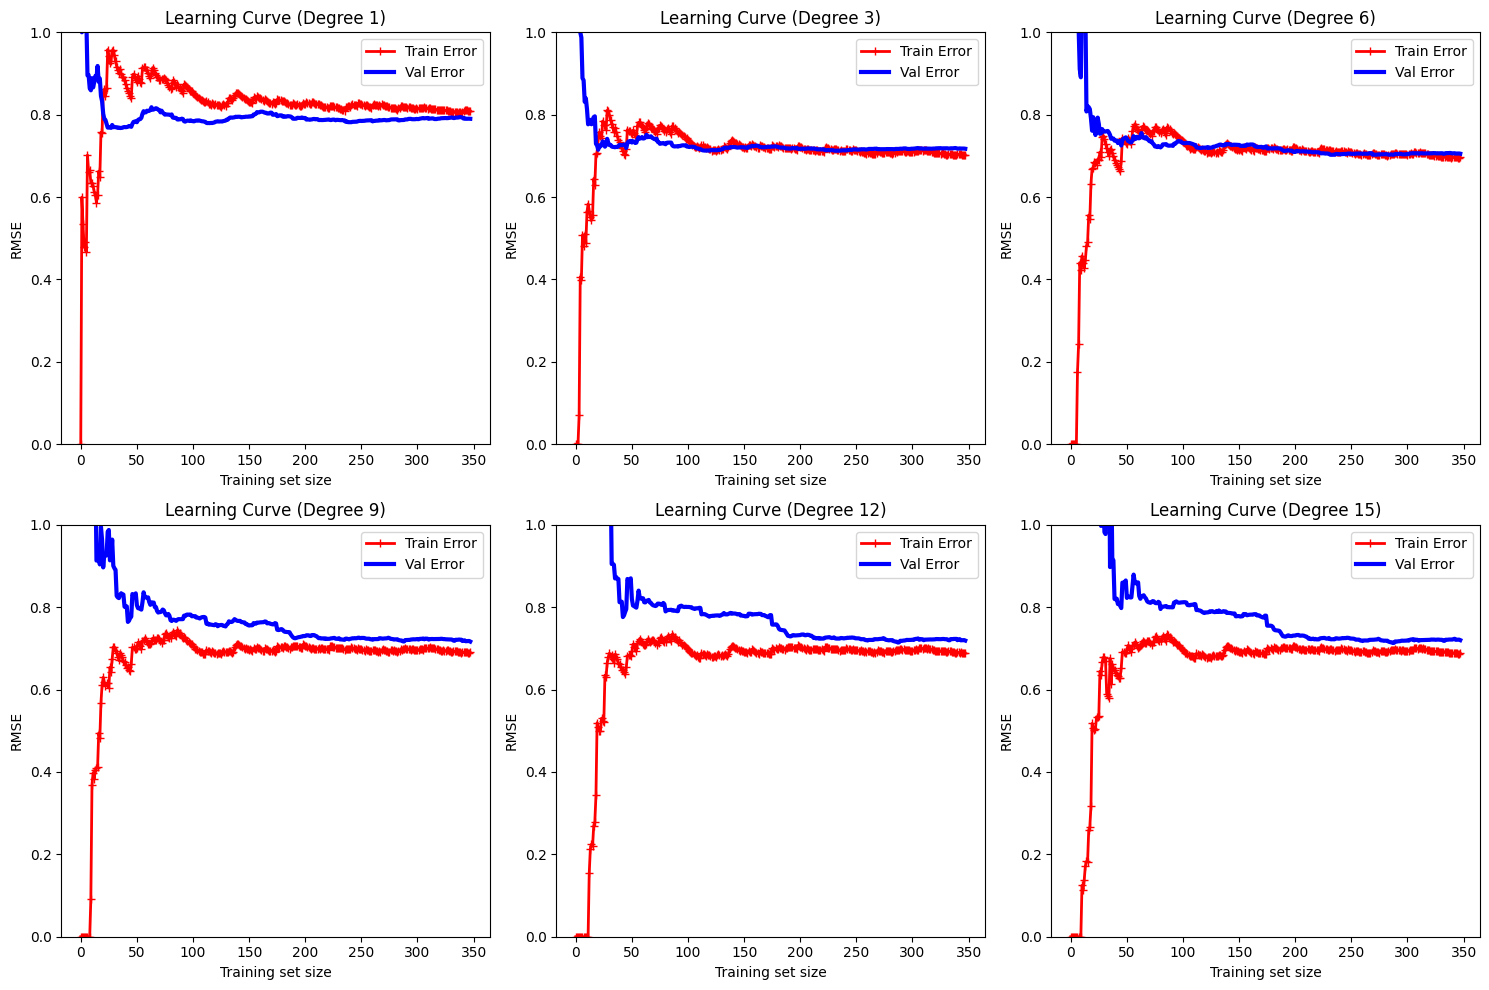

In [3]:
# Create a reusable function to plot learning curves for any degree
def plot_learning_curves(degree):
    # Lists to store errors as the training set size grows
    t_errors, v_errors = [], []
    
    # REQUIREMENT: Loop to increase training size 'm' from 2 samples to the full X_train
    # X_train[:m] means "take the first 'm' rows of the training data"
    for m in range(2, len(X_train)):
        
        # Initialize the tools (Polynomial transformer and Linear model)
        poly = PolynomialFeatures(degree=degree)
        model = LinearRegression()
        
        # 1. TRAIN: Fit the model ONLY on the first 'm' samples of the training set
        model.fit(poly.fit_transform(X_train[:m]), y_train[:m])
        
        # 2. PREDICT:
        # Predict on the SAME small 'm' samples (Training subset)
        y_train_predict = model.predict(poly.transform(X_train[:m]))
        # Predict on the FULL validation set (to see how it generalizes)
        y_val_predict = model.predict(poly.transform(X_val))
        
        # 3. COMPUTE ERROR: Store the MSE for this specific training size 'm'
        t_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        v_errors.append(mean_squared_error(y_val, y_val_predict))

    # 4. PLOTTING:
    # Use np.sqrt to turn MSE into RMSE (Root Mean Squared Error) for better scaling
    plt.plot(np.sqrt(t_errors), "r-+", linewidth=2, label="Train Error") # Red line
    plt.plot(np.sqrt(v_errors), "b-", linewidth=3, label="Val Error")   # Blue line
    
    # Keep the Y-axis between 0 and 1 so all graphs look comparable
    plt.ylim(0, 1.0) 
    plt.title(f"Learning Curve (Degree {degree})")
    plt.xlabel("Training set size") # X-axis shows the number of samples used
    plt.ylabel("RMSE")              # Y-axis shows the error amount
    plt.legend()

# EXECUTION: Loop through all degrees [1, 2, 3, 4, 5] and create a plot for each
plt.figure(figsize=(15, 10))
for i, d in enumerate(degrees):
    plt.subplot(2, 3, i+1) # Arrange plots in a grid (2 rows, 3 columns)
    plot_learning_curves(d)

plt.tight_layout()
plt.show()

In [ ]:
# Degree 1: Underfitting (High Bias)
# Observation: In the first plot, both the Train Error (Red) and Val Error (Blue) converge very quickly, but they level off at a relatively high RMSE (around 0.8).
# Explanation: This is a classic case of Underfitting. The model is a simple straight line (Degree 1) trying to fit a curved pattern. 
# No matter how much data you add, the model is "too biased" to ever learn the curve, 
# so the error stays high for both training and validation.

# 2. Degree 3 and 5: The "Sweet Spot" (Good Fit)
# Observation: As we move to Degree 3 and 5, the final RMSE for both lines drops significantly (closer to 0.7). 
# The Blue line (Validation) moves down to meet the Red line (Training) quite closely.
# Explanation: These models have the right amount of complexity. 
# They have enough "flexibility" to follow the curve of the data without being distracted by random noise. 
# This is the optimal balance in the Bias-Variance tradeoff.

# 3. Degrees 9, 12, and 15: Overfitting (High Variance)
# Observation: Look closely at the Gap between the Red and Blue lines in these plots. 
# As the degree increases from 9 to 15:
# The Train Error (Red) stays lower or continues to drop.
# The Val Error (Blue) stays significantly higher than the training error.
# There is a visible "Gap" that does not close even as the training set size reaches 350.
# Explanation: These models are Overfitting. With Degree 15, the model is so complex that it starts 
# "memorizing" the noise and jitter in the training points. 
# Because it’s memorizing noise rather than learning the actual pattern, 
# it performs much worse on the Validation Set (High Variance).